# Fig4: Plot the phylotree with the annotation
- There are two options for the plot:
  - rectangular plot with cell type annotation added to the back of sample id and bootstrap value included
# Fig4: Plot the phylotree with the annotation
- There are two options for the plot:
  - rectangular plot with cell type annotation added to the back of sample id and bootstrap value included
  - circular plot with two outer rings (tissue and cell type) and bootstrap support as integer percentages in white boxes

In [1]:
from pathlib import Path
import pandas as pd

PROJECT = Path("/home/tony/Scratch/RETrace2/2025_RETrace2_MSH2_Female_Combined")
ANNOT = PROJECT / "phylotree_annotation"
RETRACE2 = Path("/home/tony/software/RETrace2")
RSCRIPT = "/home/tony/miniconda3/envs/retrace2-R/bin/Rscript"
GGTREE_R = PROJECT / "phylo_robustness" / "view_phylo_ggtree.R"
PYTHON_RETRACE2 = "/home/tony/miniconda3/envs/retrace2/bin/python"

## Parse the pairwise dissimilarity matrix to only include the brain cells and reference

In [2]:
pd_matrix = pd.read_csv(PROJECT / "results_10000targets_3000cpgs/infer_celltype/pd_matrix/pairwise_dissimilarity_matrix.csv", index_col=0)

# Filter to only include rows and columns that start with "Brain"
brain_mask = pd_matrix.index.str.startswith("Brain")
brain_columns = pd_matrix.columns.str.startswith("Brain")

# Apply the filter to both rows and columns
pd_matrix_brain = pd_matrix.loc[brain_mask, brain_columns]

print(f"Original matrix shape: {pd_matrix.shape}")
print(f"Brain-filtered matrix shape: {pd_matrix_brain.shape}")
pd_matrix_brain.head()

Original matrix shape: (216, 24)
Brain-filtered matrix shape: (72, 24)


,Brain_Astro-Epen,Brain_CB-GABA,Brain_CB-Glut,Brain_CNU-GABA,Brain_CNU-HYa-GABA,Brain_CNU-HYa-Glut,Brain_CTX-CGE-GABA,Brain_CTX-MGE-GABA,Brain_DG-IMN-Glut,Brain_HY-GABA,...,Brain_MB-Glut,Brain_MY-GABA,Brain_MY-Glut,Brain_NP-CT-L6b-Glut,Brain_OB-IMN-GABA,Brain_OPC-Oligo,Brain_P-GABA,Brain_P-Glut,Brain_TH-Glut,Brain_Vascular
Brain_LeftAnteriorCortex_Plate1-1B,22.865519,20.806168,21.348580,18.486248,17.805782,17.911478,20.087560,18.437470,23.244026,17.566510,...,17.939288,17.509914,17.681675,18.871699,21.030609,21.789288,17.654601,17.355043,19.026523,23.454236
Brain_LeftAnteriorCortex_Plate1-1C,20.323438,19.526433,20.116516,17.882808,17.646288,17.751136,18.784685,17.992587,20.425568,17.624011,...,17.735212,17.474043,17.532798,17.707498,19.397188,20.016998,17.709877,17.364722,18.383979,21.170672
Brain_LeftAnteriorCortex_Plate1-1D,19.497021,18.555039,18.977090,17.116539,17.019929,17.032657,17.661522,17.065025,19.496822,16.998305,...,17.006584,16.924148,16.880140,16.551201,18.556745,19.069176,16.992268,16.520536,17.782699,20.168174
Brain_LeftAnteriorCortex_Plate1-1E,18.732047,17.394462,18.066302,16.679086,16.691507,16.593952,17.118682,16.513311,18.490481,16.633808,...,16.607076,16.265812,16.358824,16.353954,17.832077,18.327167,16.636442,15.991501,16.915460,19.279279
Brain_LeftAnteriorCortex_Plate1-1F,18.772679,17.854245,18.630223,16.444755,16.356944,16.317988,17.279214,16.564216,18.731018,16.347235,...,16.300603,16.197096,16.175669,16.012828,17.892415,18.576634,16.249721,15.801924,17.112310,20.087562


In [3]:
pd_matrix_brain.to_csv("pairwise_dissimilarity_matrix_brain.csv")

## Rerun the cell type inference with only the brain cells
- z-score is calculated across the reference, so best to only include only cells used
- run ./assign_celltype_command.sh

```bash
# assign cell type to the brain cells and using brain reference only
python /home/tony/software/RETrace2/modules/infer_celltype/assign_celltype.py \
    --pd_matrix ../pairwise_dissimilarity_matrix_brain.csv \
    --output_dir . \
    --threshold -1.1
```

```bash
# stdout
Generating raw PD matrix plot...
Raw PD matrix plot saved to: ./raw_pd_matrix.pdf

Calculating z-score transformation...
Z-score matrix statistics:
Mean: 0.0000
Std: 0.9789
Min: -2.1217
Max: 2.8773

Generating z-score PD matrix plot...
Z-score PD matrix plot saved to: ./zscore_pd_matrix.pdf

Creating cell type assignments...
Cell type assignments saved to: ./celltype_assignments.tsv
Z-score matrix saved to: ./zscore_matrix.csv

Assignment Summary (z-score threshold: -1.1):
Total samples: 72
Assigned samples: 47 (65.3%)
Unassigned samples: 25 (34.7%)

Assignment distribution:
  Brain_P-Glut: 30 samples
  Brain_NP-CT-L6b-Glut: 7 samples
  Brain_MY-GABA: 4 samples
  Brain_CTX-MGE-GABA: 2 samples
  Brain_HY-Glut: 2 samples
  Brain_LSX-GABA: 1 samples
  Brain_IT-ET-Glut: 1 samples

```


In [4]:
assignment_df = pd.read_csv(ANNOT / "assign_celltype" / "celltype_assignments.tsv", sep="\t")
assignment_df.head(15)

,Sample_ID,Best_Match,Min_Zscore,Second_Best_Match,Second_Best_Zscore,Passes_Threshold,Assignment
0,Brain_LeftAnteriorCortex_Plate1-1B,Brain_P-Glut,-1.076857,Brain_HY-Glut,-1.043292,False,Unassigned
1,Brain_LeftAnteriorCortex_Plate1-1C,Brain_P-Glut,-1.017076,Brain_HY-Glut,-0.951868,False,Unassigned
2,Brain_LeftAnteriorCortex_Plate1-1D,Brain_P-Glut,-1.156126,Brain_NP-CT-L6b-Glut,-1.128601,True,Brain_P-Glut
3,Brain_LeftAnteriorCortex_Plate1-1E,Brain_P-Glut,-1.304049,Brain_MY-GABA,-1.004667,True,Brain_P-Glut
4,Brain_LeftAnteriorCortex_Plate1-1F,Brain_P-Glut,-1.117610,Brain_NP-CT-L6b-Glut,-0.947090,True,Brain_P-Glut
5,Brain_LeftAnteriorCortex_Plate1-1G,Brain_P-Glut,-1.272033,Brain_MY-GABA,-0.973757,True,Brain_P-Glut
6,Brain_LeftAnteriorCortex_Plate1-2B,Brain_MY-GABA,-1.023431,Brain_HY-Glut,-1.020436,False,Unassigned
7,Brain_LeftAnteriorCortex_Plate1-2C,Brain_P-Glut,-1.078448,Brain_HY-Glut,-0.963937,False,Unassigned
8,Brain_LeftAnteriorCortex_Plate1-2D,Brain_P-Glut,-1.052162,Brain_MY-Glut,-1.001073,False,Unassigned
9,Brain_LeftAnteriorCortex_Plate1-2E,Brain_P-Glut,-1.019776,Brain_NP-CT-L6b-Glut,-1.004927,False,Unassigned


In [5]:
assignment_df['Assignment'].value_counts()

Assignment
Brain_P-Glut            30
Unassigned              25
Brain_NP-CT-L6b-Glut     7
Brain_MY-GABA            4
Brain_CTX-MGE-GABA       2
Brain_HY-Glut            2
Brain_LSX-GABA           1
Brain_IT-ET-Glut         1
Name: count, dtype: int64

# Plot 1: Rectangular plot with cell type annotation added to sample id


In [6]:
tree_file = PROJECT / "results_10000targets_3000cpgs/phylo/2025_MSH2_female_combined.buildPhylo.newick-bootstrap.txt" 

In [7]:
# Load the tree and create a mapping from tree leaf names to annotated names
from Bio import Phylo
import io

# Read the tree file
with open(tree_file, 'r') as f:
    tree_string = f.read()

# Parse the tree
tree = Phylo.read(io.StringIO(tree_string), 'newick')

# Filter assignment_df to only include cells that passed threshold
assigned_cells = assignment_df[assignment_df['Passes_Threshold'] == True].copy()

# Create the mapping dictionary from Sample_ID to Assignment
rename_map = dict(zip(assigned_cells['Sample_ID'], assigned_cells['Assignment']))

print(f"Total leaves in tree: {len(list(tree.get_terminals()))}")
print(f"Cells with assignments that passed threshold: {len(rename_map)}")
print(f"\nExample mappings:")
for i, (sample_id, assignment) in enumerate(list(rename_map.items())[:5]):
    print(f"  {sample_id} -> {sample_id}_{assignment}")

Total leaves in tree: 152
Cells with assignments that passed threshold: 47

Example mappings:
  Brain_LeftAnteriorCortex_Plate1-1D -> Brain_LeftAnteriorCortex_Plate1-1D_Brain_P-Glut
  Brain_LeftAnteriorCortex_Plate1-1E -> Brain_LeftAnteriorCortex_Plate1-1E_Brain_P-Glut
  Brain_LeftAnteriorCortex_Plate1-1F -> Brain_LeftAnteriorCortex_Plate1-1F_Brain_P-Glut
  Brain_LeftAnteriorCortex_Plate1-1G -> Brain_LeftAnteriorCortex_Plate1-1G_Brain_P-Glut
  Brain_LeftAnteriorCortex_Plate1-2G -> Brain_LeftAnteriorCortex_Plate1-2G_Brain_P-Glut


In [8]:
# Rename the leaf nodes in the tree
# Just use underscore to combine sample_id and cell type
renamed_count = 0
for leaf in tree.get_terminals():
    if leaf.name in rename_map:
        old_name = leaf.name
        new_name = f"{leaf.name}_{rename_map[leaf.name]}"
        leaf.name = new_name
        renamed_count += 1
        if renamed_count <= 5:  # Show first 5 examples
            print(f"Renamed: {old_name} -> {new_name}")

print(f"\nTotal leaves renamed: {renamed_count}")

Renamed: Brain_LeftAnteriorCortex_Plate1-4D -> Brain_LeftAnteriorCortex_Plate1-4D_Brain_P-Glut
Renamed: Brain_LeftPosteriorCortex_Plate1-5E -> Brain_LeftPosteriorCortex_Plate1-5E_Brain_NP-CT-L6b-Glut
Renamed: Brain_LeftAnteriorCortex_Plate1-1F -> Brain_LeftAnteriorCortex_Plate1-1F_Brain_P-Glut
Renamed: Brain_LeftAnteriorCortex_Plate1-4F -> Brain_LeftAnteriorCortex_Plate1-4F_Brain_P-Glut
Renamed: Brain_LeftAnteriorCortex_Plate1-4G -> Brain_LeftAnteriorCortex_Plate1-4G_Brain_HY-Glut

Total leaves renamed: 47


In [9]:
# Save the modified tree to a new file in current directory
import os
tree_filename = os.path.basename(tree_file)
output_tree_file = tree_filename.replace('.txt', '_annotated.txt')
Phylo.write(tree, output_tree_file, 'newick')

print(f"Annotated tree saved to: {output_tree_file}")

Annotated tree saved to: 2025_MSH2_female_combined.buildPhylo.newick-bootstrap_annotated.txt


In [10]:
# update samplesheet to include the annotated tree
# Just use underscore to combine sample_id and cell type
# Load the original samplesheet
samplesheet_path = PROJECT / "2025_MSH2_female_combined_samplesheet.csv"
samplesheet_df = pd.read_csv(samplesheet_path)

print(f"Original samplesheet shape: {samplesheet_df.shape}")
print(f"Original samplesheet columns: {samplesheet_df.columns.tolist()}")

# Create a new column with annotated sample_id
# For samples with assignments, add the annotation; otherwise keep original
samplesheet_df['sample_id_annotated'] = samplesheet_df['sample_id'].apply(
    lambda x: f"{x}_{rename_map[x]}" if x in rename_map else x
)

# Replace the sample_id column with the annotated version
samplesheet_df['sample_id'] = samplesheet_df['sample_id_annotated']
samplesheet_df = samplesheet_df.drop(columns=['sample_id_annotated'])

# Save the updated samplesheet to current directory
output_samplesheet_path = "2025_MSH2_female_combined_samplesheet_annotated.csv"
samplesheet_df.to_csv(output_samplesheet_path, index=False)

print(f"\nUpdated samplesheet saved to: {output_samplesheet_path}")
print(f"\nExample annotated sample_ids:")
annotated_count = 0
for i, sample_id in enumerate(samplesheet_df['sample_id'].head(20)):
    if sample_id.split('_')[-1] in ['Brain_P-Glut', 'Brain_NP-CT-L6b-Glut', 'Brain_LSX-GABA', 
                                      'Brain_CTX-MGE-GABA', 'Brain_IT-ET-Glut', 'Brain_HY-Glut']:
        print(f"  ✓ {sample_id}")
        annotated_count += 1
        if annotated_count >= 5:
            break
    else:
        if i < 3:  # Show first few non-annotated as examples
            print(f"    {sample_id}")

Original samplesheet shape: (216, 5)
Original samplesheet columns: ['sample_id', 'ms_fastq_1', 'meth_fastq_1', 'group', 'color']

Updated samplesheet saved to: 2025_MSH2_female_combined_samplesheet_annotated.csv

Example annotated sample_ids:
    Brain_LeftAnteriorCortex_Plate1-1B
    Brain_LeftAnteriorCortex_Plate1-1C
    Brain_LeftAnteriorCortex_Plate1-1D_Brain_P-Glut


## Run viewphylo to generate the annotated tree

```bash
#! /bin/bash
python /home/tony/software/RETrace2/modules/phylo/view_phylo.py \
    --samplesheet 2025_MSH2_female_combined_samplesheet_annotated.csv \
    --tree_file /home/tony/Scratch/RETrace2/2025_RETrace2_MSH2_Female_Combined/phylotree_annotation/2025_MSH2_female_combined.buildPhylo.newick-bootstrap_annotated.txt \
    --prefix 2025_MSH2_female_combined_annotated \
    --color_background \
    --bootstrap
```


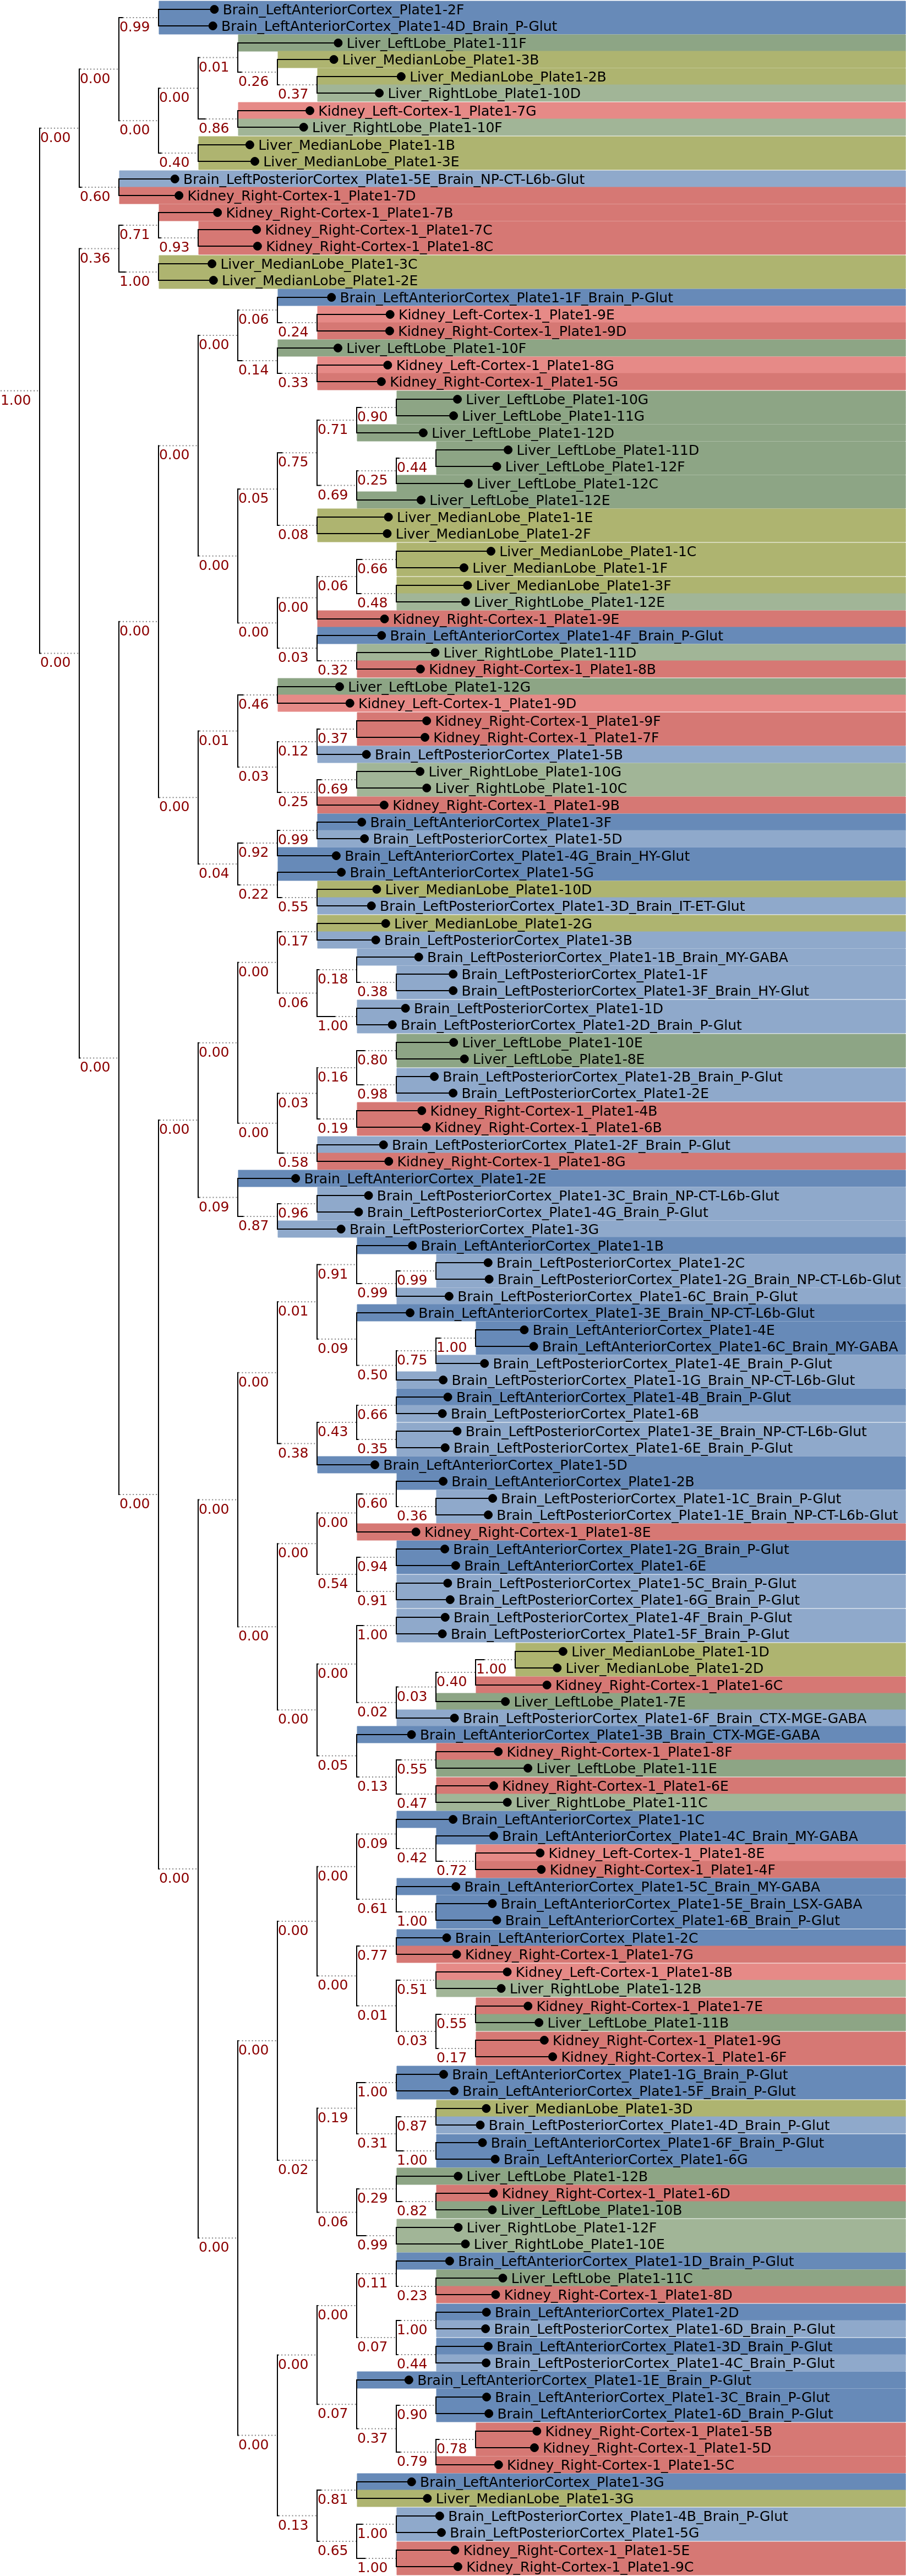

In [11]:
from IPython.display import Image, display
display(Image(str(ANNOT / "2025_MSH2_female_combined_annotated.viewPhylo.png")))

# Plot 2: Circular plot with tissue and cell type annotation as additional color layers

In [12]:
samplesheet_path = PROJECT / "2025_MSH2_female_combined_samplesheet.csv"
samplesheet_df = pd.read_csv(samplesheet_path)

In [13]:
samplesheet_df.head()

,sample_id,ms_fastq_1,meth_fastq_1,group,color
0,Brain_LeftAnteriorCortex_Plate1-1B,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,Brain_LeftAnteriorCortex,#678AB8
1,Brain_LeftAnteriorCortex_Plate1-1C,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,Brain_LeftAnteriorCortex,#678AB8
2,Brain_LeftAnteriorCortex_Plate1-1D,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,Brain_LeftAnteriorCortex,#678AB8
3,Brain_LeftAnteriorCortex_Plate1-1E,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,Brain_LeftAnteriorCortex,#678AB8
4,Brain_LeftAnteriorCortex_Plate1-1F,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,Brain_LeftAnteriorCortex,#678AB8


In [14]:
# Add cell_type_assignment and cell_type_color columns
# Define color palette for each cell type (avoiding blue/green/red used for tissues)
cell_type_colors = {
    'Brain_P-Glut': '#9B59B6',  # Purple
    'Brain_NP-CT-L6b-Glut': '#E67E22',  # Orange
    'Brain_MY-GABA': '#F1C40F',  # Yellow
    'Brain_CTX-MGE-GABA': '#E91E63',  # Magenta/Pink
    'Brain_HY-Glut': '#8B4513',  # Brown
    'Brain_LSX-GABA': '#16A085',  # Cyan/Turquoise
    'Brain_IT-ET-Glut': '#D35400',  # Dark orange
    'Unassigned (brain)': '#95A5A6',      # Medium grey: brain cells below z-score cutoff
    'Unassigned (no atlas)': '#E6E6E6',   # Light grey: kidney/liver, not submitted
}

def cell_type_label(sample_id, group):
    if sample_id in rename_map:
        return rename_map[sample_id]
    if str(group).startswith('Brain'):
        return 'Unassigned (brain)'
    return 'Unassigned (no atlas)'

samplesheet_df['cell_type_assignment'] = [
    cell_type_label(sid, grp)
    for sid, grp in zip(samplesheet_df['sample_id'], samplesheet_df['group'])
]
samplesheet_df['cell_type_color'] = samplesheet_df['cell_type_assignment'].map(cell_type_colors)

print(f"Updated samplesheet shape: {samplesheet_df.shape}")
print(f"Updated samplesheet columns: {samplesheet_df.columns.tolist()}")
print(f"\nCell type assignment distribution:")
print(samplesheet_df['cell_type_assignment'].value_counts())
print(f"\nExample rows with cell type annotations:")
assigned_mask = ~samplesheet_df['cell_type_assignment'].str.startswith('Unassigned')
samplesheet_df[assigned_mask].head(10)


Updated samplesheet shape: (216, 7)
Updated samplesheet columns: ['sample_id', 'ms_fastq_1', 'meth_fastq_1', 'group', 'color', 'cell_type_assignment', 'cell_type_color']

Cell type assignment distribution:
cell_type_assignment
Unassigned (no atlas)    144
Brain_P-Glut              30
Unassigned (brain)        25
Brain_NP-CT-L6b-Glut       7
Brain_MY-GABA              4
Brain_CTX-MGE-GABA         2
Brain_HY-Glut              2
Brain_LSX-GABA             1
Brain_IT-ET-Glut           1
Name: count, dtype: int64

Example rows with cell type annotations:


,sample_id,ms_fastq_1,meth_fastq_1,group,color,cell_type_assignment,cell_type_color
2,Brain_LeftAnteriorCortex_Plate1-1D,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,Brain_LeftAnteriorCortex,#678AB8,Brain_P-Glut,#9B59B6
3,Brain_LeftAnteriorCortex_Plate1-1E,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,Brain_LeftAnteriorCortex,#678AB8,Brain_P-Glut,#9B59B6
4,Brain_LeftAnteriorCortex_Plate1-1F,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,Brain_LeftAnteriorCortex,#678AB8,Brain_P-Glut,#9B59B6
5,Brain_LeftAnteriorCortex_Plate1-1G,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,Brain_LeftAnteriorCortex,#678AB8,Brain_P-Glut,#9B59B6
11,Brain_LeftAnteriorCortex_Plate1-2G,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,Brain_LeftAnteriorCortex,#678AB8,Brain_P-Glut,#9B59B6
12,Brain_LeftAnteriorCortex_Plate1-3B,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,Brain_LeftAnteriorCortex,#678AB8,Brain_CTX-MGE-GABA,#E91E63
13,Brain_LeftAnteriorCortex_Plate1-3C,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,Brain_LeftAnteriorCortex,#678AB8,Brain_P-Glut,#9B59B6
14,Brain_LeftAnteriorCortex_Plate1-3D,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,Brain_LeftAnteriorCortex,#678AB8,Brain_P-Glut,#9B59B6
15,Brain_LeftAnteriorCortex_Plate1-3E,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,Brain_LeftAnteriorCortex,#678AB8,Brain_NP-CT-L6b-Glut,#E67E22
18,Brain_LeftAnteriorCortex_Plate1-4B,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,/datasets/s3/altos-lab-kzhang/tcheng/retrace2-...,Brain_LeftAnteriorCortex,#678AB8,Brain_P-Glut,#9B59B6


In [15]:
# Save the updated samplesheet with cell type annotations
output_samplesheet_path = "2025_MSH2_female_combined_samplesheet_with_celltype.csv"
samplesheet_df.to_csv(output_samplesheet_path, index=False)


## Run Rscript to generate the circular plot and ring layers
- run `phylo_robustness/view_phylo_ggtree.R` with `--show_bootstrap`
- bootstrap support is shown as integer percentages in small white boxes (same style as the HCT116 circular trees)

```bash
# Circular tree with tissue + cell-type rings and bootstrap percentages in white boxes
/home/tony/miniconda3/envs/retrace2-R/bin/Rscript \
  /home/tony/Scratch/RETrace2/2025_RETrace2_MSH2_Female_Combined/phylo_robustness/view_phylo_ggtree.R \
  --samplesheet 2025_MSH2_female_combined_samplesheet_with_celltype.csv \
  --tree_file /home/tony/Scratch/RETrace2/2025_RETrace2_MSH2_Female_Combined/results_10000targets_3000cpgs/phylo/2025_MSH2_female_combined.buildPhylo.newick-bootstrap.txt \
  --prefix 2025_MSH2_female_combined_with_celltype_circular_ring_bootstrap \
  --show_bootstrap
```

In [16]:
import subprocess
from IPython.display import Image, display

prefix = ANNOT / "2025_MSH2_female_combined_with_celltype_circular_ring_bootstrap"
cmd = [
    RSCRIPT,
    str(GGTREE_R),
    "--samplesheet", str(ANNOT / "2025_MSH2_female_combined_samplesheet_with_celltype.csv"),
    "--tree_file", str(PROJECT / "results_10000targets_3000cpgs/phylo/2025_MSH2_female_combined.buildPhylo.newick-bootstrap.txt"),
    "--prefix", str(prefix),
    "--show_bootstrap",
]
print(" ".join(cmd))
result = subprocess.run(cmd, cwd=str(ANNOT), capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("view_phylo_ggtree.R failed")

display(Image(str(prefix) + ".viewPhylo.png"))

/home/tony/miniconda3/envs/retrace2-R/bin/Rscript /home/tony/Scratch/RETrace2/2025_RETrace2_MSH2_Female_Combined/phylo_robustness/view_phylo_ggtree.R --samplesheet /home/tony/Scratch/RETrace2/2025_RETrace2_MSH2_Female_Combined/phylotree_annotation/2025_MSH2_female_combined_samplesheet_with_celltype.csv --tree_file /home/tony/Scratch/RETrace2/2025_RETrace2_MSH2_Female_Combined/results_10000targets_3000cpgs/phylo/2025_MSH2_female_combined.buildPhylo.newick-bootstrap.txt --prefix /home/tony/Scratch/RETrace2/2025_RETrace2_MSH2_Female_Combined/phylotree_annotation/2025_MSH2_female_combined_with_celltype_circular_ring_bootstrap --show_bootstrap


Using Newick node labels as bootstrap/support (integer percentages).
Joined bootstrap values (labels drawn after the outer rings).
Added bootstrap support values at internal nodes.
Tree visualization saved to:
  /home/tony/Scratch/RETrace2/2025_RETrace2_MSH2_Female_Combined/phylotree_annotation/2025_MSH2_female_combined_with_celltype_circular_ring_bootstrap.viewPhylo.pdf
  /home/tony/Scratch/RETrace2/2025_RETrace2_MSH2_Female_Combined/phylotree_annotation/2025_MSH2_female_combined_with_celltype_circular_ring_bootstrap.viewPhylo.png



# Tissue Bias Analysis

Analyze clonal/clade bias toward different tissues (Brain, Kidney, Liver)


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import hypergeom, fisher_exact, chi2_contingency
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from Bio import Phylo
import io
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')


In [18]:
# Load the phylogenetic tree
tree_file = PROJECT / "results_10000targets_3000cpgs/phylo/2025_MSH2_female_combined.buildPhylo.newick-bootstrap.txt"

with open(tree_file, 'r') as f:
    tree_string = f.read()

tree = Phylo.read(io.StringIO(tree_string), 'newick')

print(f"Total leaves in tree: {len(list(tree.get_terminals()))}")

# Load samplesheet to get GRANULAR tissue information
samplesheet = pd.read_csv(PROJECT / "2025_MSH2_female_combined_samplesheet.csv")
sample_to_tissue = dict(zip(samplesheet['sample_id'], samplesheet['group']))

# Extract granular tissue information from sample IDs
leaf_names = [leaf.name for leaf in tree.get_terminals()]
tissue_info = {}
for leaf in leaf_names:
    if leaf in sample_to_tissue:
        tissue_info[leaf] = sample_to_tissue[leaf]
    else:
        parts = leaf.split('_')
        if len(parts) >= 2:
            tissue_info[leaf] = '_'.join(parts[:2])
        else:
            tissue_info[leaf] = parts[0]

# Count tissues at granular level
tissue_counts = pd.Series(tissue_info.values()).value_counts()
print(f"\nGranular tissue distribution:")
print(tissue_counts)


Total leaves in tree: 152

Granular tissue distribution:
Brain_LeftPosteriorCortex    36
Brain_LeftAnteriorCortex     35
Kidney_Right-Cortex-1        30
Liver_LeftLobe               18
Liver_MedianLobe             17
Liver_RightLobe              10
Kidney_Left-Cortex-1          6
Name: count, dtype: int64


## Recursive Tree Traversal to Identify Major Clades of 10-20 Cells


In [19]:
def find_major_clades(clade, min_size=10, max_size=20, collected_clades=None, used_leaves=None):
    """
    Recursively traverses the phylogenetic tree to find non-overlapping clades 
    (subtrees) containing between 10 and 20 cells.
    """
    if collected_clades is None:
        collected_clades = []
    if used_leaves is None:
        used_leaves = set()
    
    leaves = [leaf.name for leaf in clade.get_terminals()]
    size = len(leaves)
    
    if min_size <= size <= max_size and not set(leaves) & used_leaves:
        collected_clades.append((size, clade, leaves))
        used_leaves.update(leaves)
        return
    
    elif size > max_size and not clade.is_terminal():
        for subclade in clade.clades:
            find_major_clades(subclade, min_size, max_size, collected_clades, used_leaves)
    
    return collected_clades

# Find clades starting from root
clades = find_major_clades(tree.root, min_size=10, max_size=20)
clades.sort(reverse=True, key=lambda x: x[0])

print(f"Found {len(clades)} major clades in size range 10-20")

if len(clades) > 0:
    print("\nFirst 10 clades:")
    for i, (size, clade, leaf_names) in enumerate(clades[:10]):
        print(f"  Clade {i+1}: {size} cells")
        tissues_in_clade = [tissue_info.get(name, 'Unknown') for name in leaf_names]
        tissue_dist = pd.Series(tissues_in_clade).value_counts()
        # Convert to regular Python int for clean display
        tissue_dict = {k: int(v) for k, v in tissue_dist[:3].items()}
        print(f"    Top tissues: {tissue_dict}")
        print(f"    Sample IDs: {leaf_names}")


Found 9 major clades in size range 10-20

First 10 clades:
  Clade 1: 20 cells
    Top tissues: {'Brain_LeftPosteriorCortex': 7, 'Brain_LeftAnteriorCortex': 4, 'Kidney_Right-Cortex-1': 4}
    Sample IDs: ['Brain_LeftAnteriorCortex_Plate1-2B', 'Brain_LeftPosteriorCortex_Plate1-1C', 'Brain_LeftPosteriorCortex_Plate1-1E', 'Kidney_Right-Cortex-1_Plate1-8E', 'Brain_LeftAnteriorCortex_Plate1-2G', 'Brain_LeftAnteriorCortex_Plate1-6E', 'Brain_LeftPosteriorCortex_Plate1-5C', 'Brain_LeftPosteriorCortex_Plate1-6G', 'Brain_LeftPosteriorCortex_Plate1-4F', 'Brain_LeftPosteriorCortex_Plate1-5F', 'Liver_MedianLobe_Plate1-1D', 'Liver_MedianLobe_Plate1-2D', 'Kidney_Right-Cortex-1_Plate1-6C', 'Liver_LeftLobe_Plate1-7E', 'Brain_LeftPosteriorCortex_Plate1-6F', 'Brain_LeftAnteriorCortex_Plate1-3B', 'Kidney_Right-Cortex-1_Plate1-8F', 'Liver_LeftLobe_Plate1-11E', 'Kidney_Right-Cortex-1_Plate1-6E', 'Liver_RightLobe_Plate1-11C']
  Clade 2: 19 cells
    Top tissues: {'Brain_LeftPosteriorCortex': 12, 'Kidney_Righ

## Tissue Bias Analysis

**Statistical Method:** Hypergeometric test + Benjamini-Hochberg FDR correction

**3-Level Bias Classification:**
- ★★★ **Strong**: FDR<0.05, FC≥2.0 (high confidence, large effect)
- ★★ **Moderate**: FDR<0.1, FC≥1.5 (moderate confidence & effect)
- ★ **Weak**: FDR<0.2, FC>1.0 (suggestive evidence)
- **Multipotent**: No significant enrichment


In [20]:
# Define the test_tissue_bias function
def test_tissue_bias(cluster_tissues, all_tissues, tissue_types=None):
    """Test for tissue bias in a cluster using hypergeometric test"""
    results = {
        'cluster_size': len(cluster_tissues),
        'tissue_counts': {},
        'tissue_fractions': {},
        'expected_counts': {},
        'fold_changes': {},
        'hypergeom_pvalues': {},
        'enriched_tissues': []
    }
    
    total_cells = len(all_tissues)
    cluster_size = len(cluster_tissues)
    
    cluster_tissue_counts = pd.Series(cluster_tissues).value_counts()
    overall_tissue_counts = pd.Series(all_tissues).value_counts()
    
    if tissue_types is None:
        tissue_types = sorted(overall_tissue_counts.index.tolist())
    
    # Test each tissue
    for tissue in tissue_types:
        k = cluster_tissue_counts.get(tissue, 0)
        M = total_cells
        n = overall_tissue_counts.get(tissue, 0)
        N = cluster_size
        
        expected = (n / M) * N
        observed_fraction = k / N if N > 0 else 0
        expected_fraction = n / M if M > 0 else 0
        fold_change = observed_fraction / expected_fraction if expected_fraction > 0 else 0
        
        if k > 0:
            pval_enrichment = 1 - hypergeom.cdf(k-1, M, n, N)
        else:
            pval_enrichment = 1.0
        
        results['tissue_counts'][tissue] = k
        results['tissue_fractions'][tissue] = observed_fraction
        results['expected_counts'][tissue] = expected
        results['fold_changes'][tissue] = fold_change
        results['hypergeom_pvalues'][tissue] = pval_enrichment
        
    # Perform overall chi-square test
    observed = [cluster_tissue_counts.get(t, 0) for t in tissue_types]
    expected = [results['expected_counts'][t] for t in tissue_types]
    
    if cluster_size >= 5 and all(e > 0 for e in expected):
        chi2, chi2_pval, dof, expected_freq = chi2_contingency([observed, expected])
        results['chi2_pval'] = chi2_pval
    else:
        results['chi2_pval'] = 1.0
    
    # Identify significantly enriched tissues (FDR < 0.2)
    from statsmodels.stats.multitest import multipletests
    pvals = [results['hypergeom_pvalues'][t] for t in tissue_types]
    rejected, pvals_corrected, _, _ = multipletests(pvals, alpha=0.2, method='fdr_bh')
    
    for i, tissue in enumerate(tissue_types):
        if rejected[i] and results['fold_changes'][tissue] > 1.0:
            results['enriched_tissues'].append(tissue)
    
    return results

# Get all unique granular tissues
all_unique_tissues = sorted(set(tissue_info.values()))

# Define broad organ mapping
organ_map = {
    t: 'Brain' if t.startswith('Brain') else 
      'Kidney' if t.startswith('Kidney') else 
      'Liver' if t.startswith('Liver') else 'Unknown'
    for t in all_unique_tissues
}

print("Running tissue bias analysis...")
print("=" * 80)

# Define multi-level bias classification function
def classify_bias_level(enriched_tissues, fold_changes, hypergeom_pvalues):
    """Classify bias strength: ★★★, ★★, ★, or Multipotent"""
    if not enriched_tissues:
        return 0, 'Multipotent', 0, None
    
    max_fc = 0
    best_tissue = None
    best_pval = 1.0
    
    for tissue in enriched_tissues:
        fc = fold_changes[tissue]
        pval = hypergeom_pvalues[tissue]
        if fc > max_fc:
            max_fc = fc
            best_tissue = tissue
            best_pval = pval
    
    # Multi-level classification
    if best_pval < 0.05 and max_fc >= 2.0:
        return 3, '★★★', max_fc, best_tissue
    elif best_pval < 0.1 and max_fc >= 1.5:
        return 2, '★★', max_fc, best_tissue
    elif best_pval < 0.2 and max_fc > 1.0:
        return 1, '★', max_fc, best_tissue
    else:
        return 0, 'Multipotent', max_fc, best_tissue


Running tissue bias analysis...


In [21]:
# Perform bias analysis and compute tissue compositions
all_tissues_list = list(tissue_info.values())
bias_results = []
clade_compositions = []

for i, (size, _, leaf_names) in enumerate(clades):
    cluster_tissues = [tissue_info.get(name, 'Unknown') for name in leaf_names]
    
    # Perform statistical test
    result = test_tissue_bias(cluster_tissues, all_tissues_list)
    result['clade_id'] = f"Clade {i+1}"
    result['clade_size'] = size
    result['leaf_names'] = leaf_names
    bias_results.append(result)
    
    # Compute tissue composition (percentages)
    tissue_counts = pd.Series(cluster_tissues).value_counts(normalize=True) * 100
    composition = {t: tissue_counts.get(t, 0) for t in all_unique_tissues}
    
    # Classify bias level using 3-star system
    bias_level, bias_label, max_fc, best_tissue = classify_bias_level(
        result['enriched_tissues'], 
        result['fold_changes'], 
        result['hypergeom_pvalues']
    )
    
    if result['enriched_tissues']:
        bias_status = 'BIASED'
        dominant_enriched_organ = organ_map.get(best_tissue, 'Unknown')
    else:
        bias_status = 'MULTIPOTENT'
        dominant_enriched_organ = 'MULTIPOTENT'
    
    clade_compositions.append({
        'clade_id': f"Clade {i+1} (n={size})",
        'clade_number': i+1,
        'bias_status': bias_status,
        'bias_level': bias_level,
        'bias_label': bias_label,
        'dominant_enriched_organ': dominant_enriched_organ,
        'max_fold_change': max_fc,
        'best_tissue': best_tissue,
        **composition
    })

print(f"\nProcessed {len(clades)} clades")
print(f"\n3-Level Bias Classification:")
print(f"  ★★★ Strong:   {sum(c['bias_level'] == 3 for c in clade_compositions)} clades (FDR<0.05, FC≥2.0)")
print(f"  ★★  Moderate: {sum(c['bias_level'] == 2 for c in clade_compositions)} clades (FDR<0.1, FC≥1.5)")
print(f"  ★   Weak:     {sum(c['bias_level'] == 1 for c in clade_compositions)} clades (FDR<0.2, FC>1.0)")
print(f"      Multipotent: {sum(c['bias_level'] == 0 for c in clade_compositions)} clades")

# Define colors for granular tissues
tissue_colors = {
    'Brain_LeftAnteriorCortex': '#678AB8',  
    'Brain_LeftPosteriorCortex': '#8FA9CB',         
    'Kidney_Left-Cortex-1': '#E68A87',            
    'Kidney_Right-Cortex-1': '#D67874',           
    'Liver_LeftLobe': '#8DA585',                  
    'Liver_RightLobe': '#A1B597',                 
    'Liver_MedianLobe': '#AEB470'                  
}
colors = [tissue_colors.get(t, '#95A5A6') for t in all_unique_tissues]



Processed 9 clades

3-Level Bias Classification:
  ★★★ Strong:   3 clades (FDR<0.05, FC≥2.0)
  ★★  Moderate: 0 clades (FDR<0.1, FC≥1.5)
  ★   Weak:     0 clades (FDR<0.2, FC>1.0)
      Multipotent: 6 clades


## Tissue Composition by Clade

Stacked bar plot showing tissue composition for each clade with bias level indicators (★★★, ★★, ★).


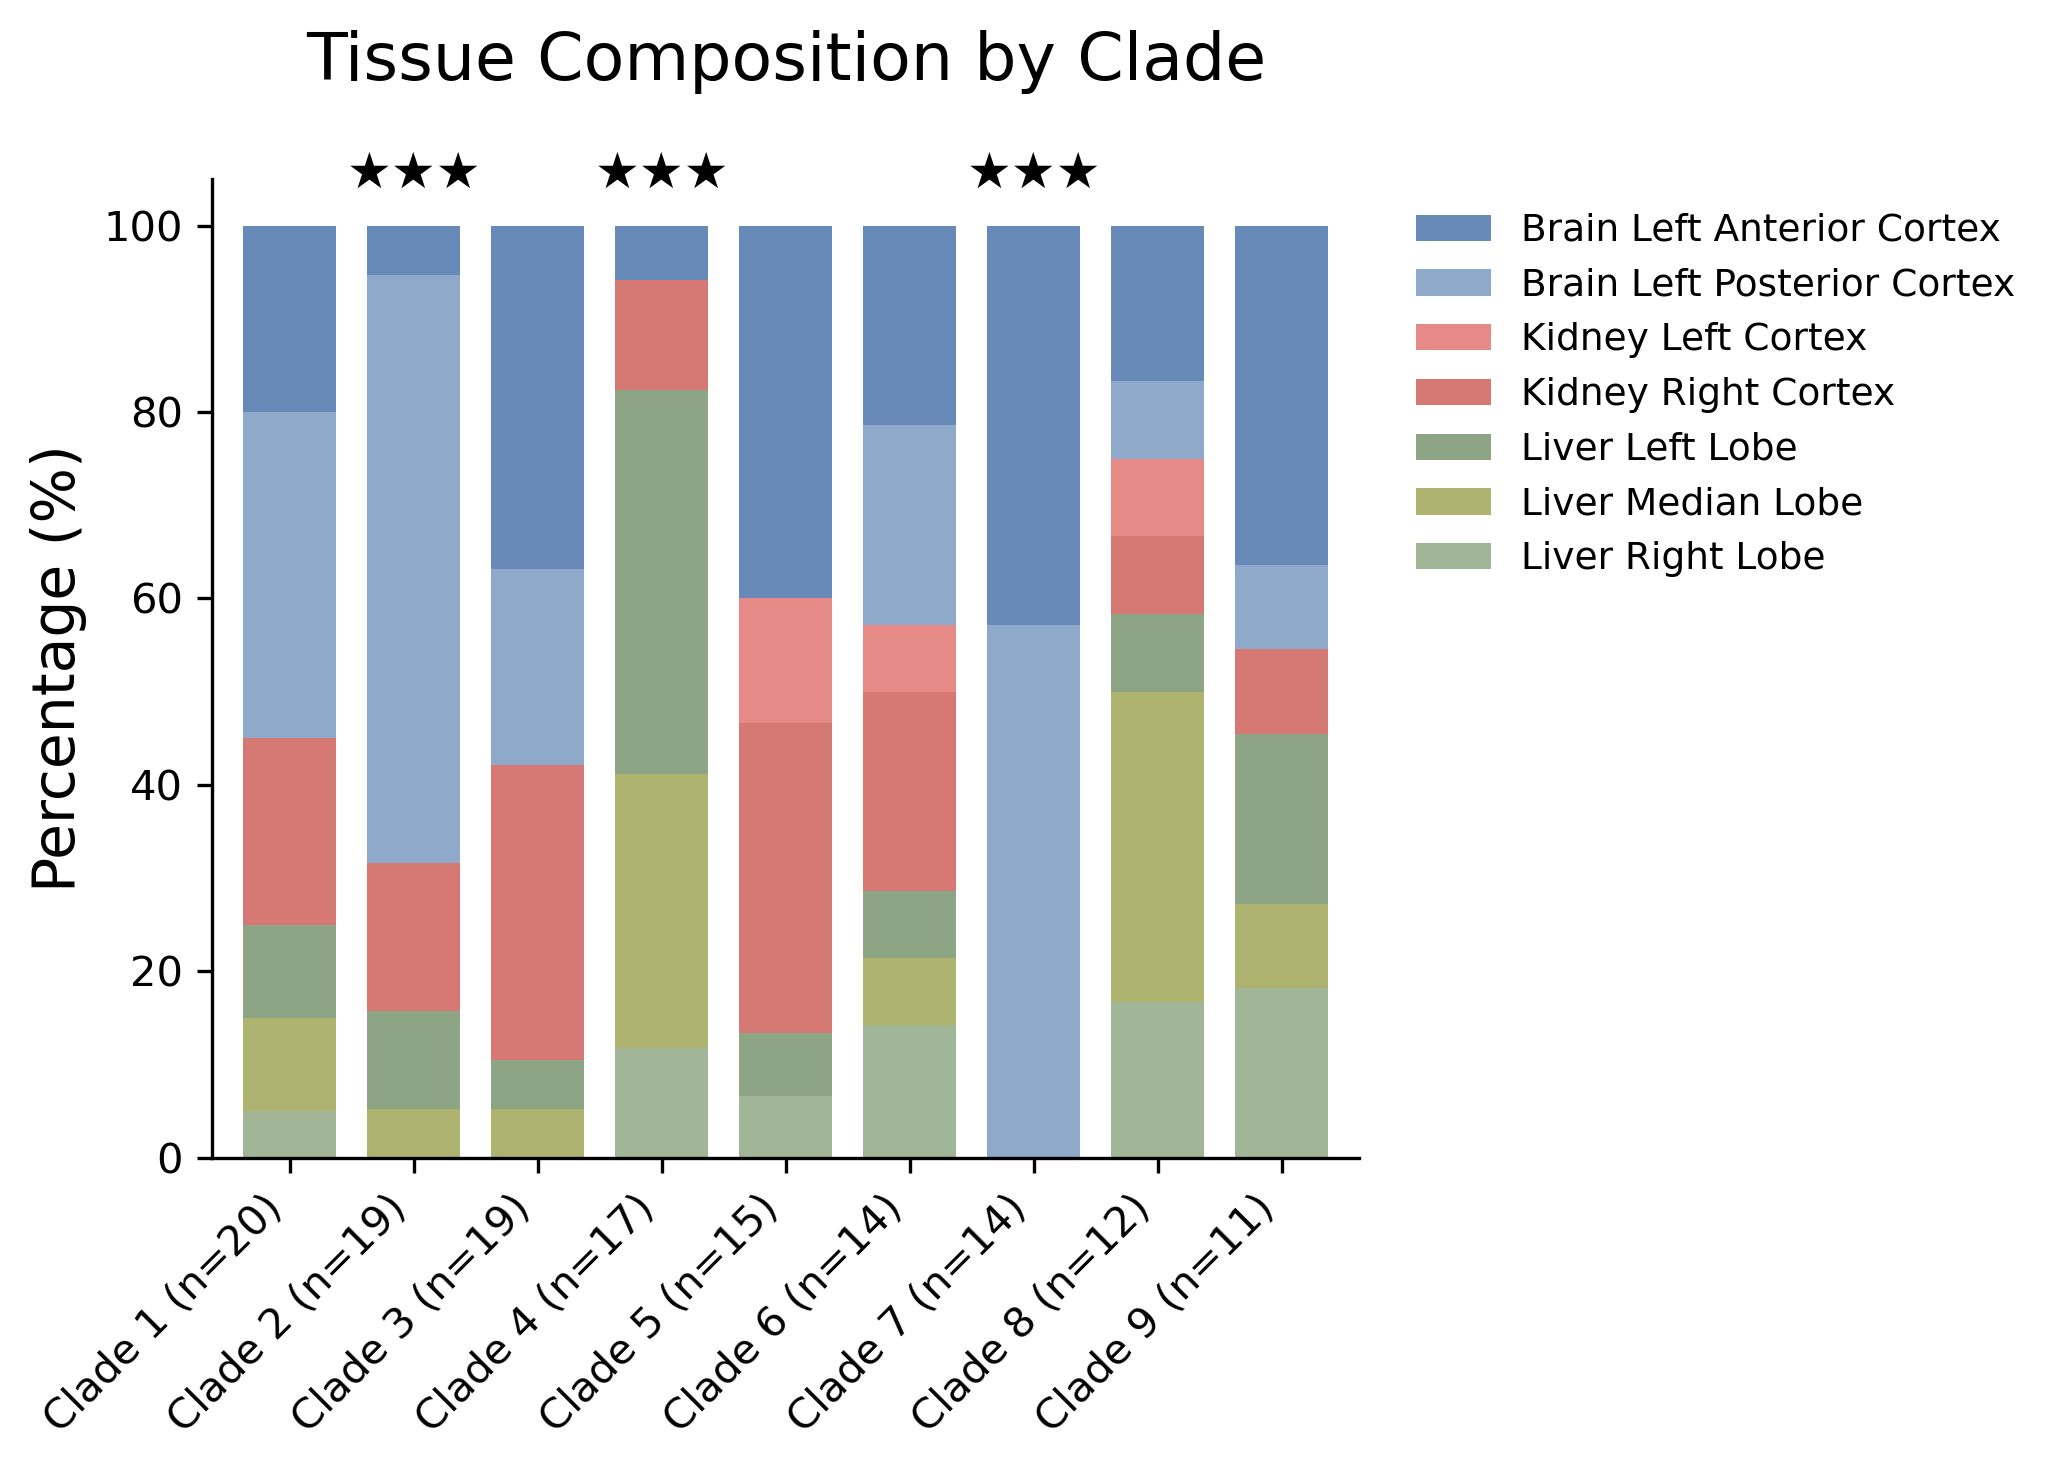

Legend: ★★★=Strong | ★★=Moderate | ★=Weak | (blank)=Multipotent


In [22]:
# Create stacked bar plot in numerical order (Clade 1-9)
clade_df_plot = pd.DataFrame(clade_compositions).sort_values('clade_number')

# Rename dictionary for cleaner tissue names
rename_dict = {'Brain_LeftAnteriorCortex': 'Brain Left Anterior Cortex',
                'Brain_LeftPosteriorCortex': 'Brain Left Posterior Cortex',
                'Kidney_Left-Cortex-1': 'Kidney Left Cortex',
                'Kidney_Right-Cortex-1': 'Kidney Right Cortex',
                'Liver_LeftLobe': 'Liver Left Lobe',
                'Liver_MedianLobe': 'Liver Median Lobe',
                'Liver_RightLobe': 'Liver Right Lobe'}

# Rename columns for display
clade_df_renamed = clade_df_plot.set_index('clade_id')[all_unique_tissues].rename(columns=rename_dict)

# Reverse column order so stacking matches legend order (top to bottom)
clade_df_renamed = clade_df_renamed.iloc[:, ::-1]

# Reverse colors to match the reversed column order
colors_reversed = colors[::-1]

# Create narrower plot for publication
fig, ax = plt.subplots(figsize=(7, 5), dpi=300)
clade_df_renamed.plot(
    kind='bar', stacked=True, ax=ax, color=colors_reversed, width=0.75
)

# Add bias level stars above each bar
for i, (idx, row) in enumerate(clade_df_plot.iterrows()):
    if row['bias_level'] > 0:
        ax.text(i, 103, row['bias_label'], ha='center', va='bottom', 
                fontsize=12, fontweight='bold', color='black')

ax.set_title('Tissue Composition by Clade\n', fontsize=16)
ax.set_ylabel('Percentage (%)', fontsize=14)
ax.set_xlabel('', fontsize=14)

ax.set_ylim(0, 105)
plt.xticks(rotation=45, ha='right', fontsize=10)

# Reverse legend order back to original since we reversed the data
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.savefig('Fig4_clade_tissue_composition.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("Legend: ★★★=Strong | ★★=Moderate | ★=Weak | (blank)=Multipotent")


## Detailed Clade-by-Clade Results


In [23]:
# Print detailed results for each clade
print("\n" + "=" * 80)
print("DETAILED RESULTS FOR EACH CLADE")
print("=" * 80)

for i, result in enumerate(bias_results):
    size = result['clade_size']
    comp = clade_compositions[i]
    
    print(f"\n{result['clade_id']} (n={size}) - {comp['bias_label']}")
    
    if result['enriched_tissues']:
        print(f"  ✓ Enriched tissues:")
        for tissue in result['enriched_tissues']:
            fc = result['fold_changes'][tissue]
            pval = result['hypergeom_pvalues'][tissue]
            count = result['tissue_counts'][tissue]
            print(f"    • {tissue}: {count}/{size} cells ({count/size*100:.1f}%), FC={fc:.2f}, p={pval:.2e}")
    else:
        print(f"  • No significant tissue enrichment (multipotent)")
    
    # Show top tissues by raw count
    cluster_tissues = [tissue_info.get(name, 'Unknown') for name in result['leaf_names']]
    tissue_counts_in_clade = pd.Series(cluster_tissues).value_counts()
    # Convert to regular Python int for clean display
    tissue_dict = {k: int(v) for k, v in tissue_counts_in_clade.head(3).items()}
    print(f"  Top tissues: {tissue_dict}")

print("\n" + "=" * 80)



DETAILED RESULTS FOR EACH CLADE

Clade 1 (n=20) - Multipotent
  • No significant tissue enrichment (multipotent)
  Top tissues: {'Brain_LeftPosteriorCortex': 7, 'Brain_LeftAnteriorCortex': 4, 'Kidney_Right-Cortex-1': 4}

Clade 2 (n=19) - ★★★
  ✓ Enriched tissues:
    • Brain_LeftPosteriorCortex: 12/19 cells (63.2%), FC=2.67, p=9.09e-05
  Top tissues: {'Brain_LeftPosteriorCortex': 12, 'Kidney_Right-Cortex-1': 3, 'Liver_LeftLobe': 2}

Clade 3 (n=19) - Multipotent
  • No significant tissue enrichment (multipotent)
  Top tissues: {'Brain_LeftAnteriorCortex': 7, 'Kidney_Right-Cortex-1': 6, 'Brain_LeftPosteriorCortex': 4}

Clade 4 (n=17) - ★★★
  ✓ Enriched tissues:
    • Liver_LeftLobe: 7/17 cells (41.2%), FC=3.48, p=9.48e-04
    • Liver_MedianLobe: 5/17 cells (29.4%), FC=2.63, p=2.55e-02
  Top tissues: {'Liver_LeftLobe': 7, 'Liver_MedianLobe': 5, 'Liver_RightLobe': 2}

Clade 5 (n=15) - Multipotent
  • No significant tissue enrichment (multipotent)
  Top tissues: {'Brain_LeftAnteriorCortex'

## Summary Table


In [24]:
# Create summary table
summary_data = []

for result in bias_results:
    clade_id = result['clade_id']
    clade_size = result['clade_size']
    
    tissue_counts = result['tissue_counts']
    sorted_tissues = sorted(tissue_counts.items(), key=lambda x: x[1], reverse=True)
    top_tissues = ', '.join([f"{t}({c})" for t, c in sorted_tissues[:3] if c > 0])
    
    if result['enriched_tissues']:
        enriched_str = []
        for tissue in result['enriched_tissues']:
            fc = result['fold_changes'][tissue]
            pval = result['hypergeom_pvalues'][tissue]
            enriched_str.append(f"{tissue} (FC={fc:.2f}, p={pval:.2e})")
        enriched_tissues_str = '; '.join(enriched_str)
        bias_status = "BIASED"
    else:
        enriched_tissues_str = "None"
        bias_status = "MULTIPOTENT"
    
    clade_comp = next(c for c in clade_compositions if c['clade_id'] == f"Clade {clade_id.split()[1]} (n={clade_size})")
    bias_label = clade_comp['bias_label']
    
    summary_data.append({
        'Clade': clade_id,
        'Size': clade_size,
        'Bias Level': bias_label,
        'Status': bias_status,
        'Top Tissues': top_tissues,
        'Enriched Tissues': enriched_tissues_str
    })

summary_df = pd.DataFrame(summary_data)

print("\n" + "=" * 100)
print("TISSUE BIAS ANALYSIS SUMMARY")
print("=" * 100)
print(f"\nTotal clades: {len(summary_df)}")
print(f"Biased: {(summary_df['Status'] == 'BIASED').sum()}")
print(f"Multipotent: {(summary_df['Status'] == 'MULTIPOTENT').sum()}")
print("\n")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
print(summary_df.to_string(index=False))

print("\n" + "=" * 100)



TISSUE BIAS ANALYSIS SUMMARY

Total clades: 9
Biased: 3
Multipotent: 6


  Clade  Size  Bias Level      Status                                                                         Top Tissues                                                             Enriched Tissues
Clade 1    20 Multipotent MULTIPOTENT Brain_LeftPosteriorCortex(7), Brain_LeftAnteriorCortex(4), Kidney_Right-Cortex-1(4)                                                                         None
Clade 2    19         ★★★      BIASED          Brain_LeftPosteriorCortex(12), Kidney_Right-Cortex-1(3), Liver_LeftLobe(2)                              Brain_LeftPosteriorCortex (FC=2.67, p=9.09e-05)
Clade 3    19 Multipotent MULTIPOTENT Brain_LeftAnteriorCortex(7), Kidney_Right-Cortex-1(6), Brain_LeftPosteriorCortex(4)                                                                         None
Clade 4    17         ★★★      BIASED                    Liver_LeftLobe(7), Liver_MedianLobe(5), Kidney_Right-Cortex-1(2) Liver_Le